In [1]:
!pip install torch torchvision matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 69.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Hyperparameters
batch_size = 128
z_dim = 100
lr = 0.0002
num_epochs = 100

# Data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
mnist = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
dataloader = torch.utils.data.DataLoader(mnist, batch_size=batch_size, shuffle=True)

# Generator
class Generator(nn.Module):
    def __init__(self, z_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 28*28),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z).view(-1, 1, 28, 28)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x.view(-1, 28*28))

# Initialize models
G = Generator(z_dim).cuda()
D = Discriminator().cuda()

# Loss and optimizers
criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=lr)
optimizer_D = optim.Adam(D.parameters(), lr=lr)

# Labels
real_label = 1.
fake_label = 0.

losses_G, losses_D = [], []

# Training loop
for epoch in range(num_epochs):
    for i, (real_images, _) in enumerate(dataloader):
        real_images = real_images.cuda()
        batch_size = real_images.size(0)

        # Train Discriminator
        z = torch.randn(batch_size, z_dim).cuda()
        fake_images = G(z)
        D_real = D(real_images)
        D_fake = D(fake_images.detach())
        loss_D = criterion(D_real, torch.ones_like(D_real)) + criterion(D_fake, torch.zeros_like(D_fake))
        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # Train Generator
        z = torch.randn(batch_size, z_dim).cuda()
        fake_images = G(z)
        D_fake = D(fake_images)
        loss_G = criterion(D_fake, torch.ones_like(D_fake))
        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

    losses_G.append(loss_G.item())
    losses_D.append(loss_D.item())

    if epoch in [0, 50, 100]:
        fake_images = fake_images[:25].cpu().detach()
        grid = torchvision.utils.make_grid(fake_images, nrow=5, normalize=True)
        plt.imshow(grid.permute(1, 2, 0))
        plt.title(f'Epoch {epoch}')
        plt.savefig(f'epoch_{epoch}.png')
        plt.close()
    print(f'Epoch [{epoch}/{num_epochs}] Loss D: {loss_D.item()}, Loss G: {loss_G.item()}')

# Plot losses
plt.plot(losses_G, label='Generator Loss')
plt.plot(losses_D, label='Discriminator Loss')
plt.legend()
plt.savefig('loss_plot.png')
plt.close()


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.81MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.45MB/s]


Epoch [0/100] Loss D: 0.048269547522068024, Loss G: 7.114279747009277
Epoch [1/100] Loss D: 0.1716427505016327, Loss G: 5.750021934509277
Epoch [2/100] Loss D: 0.29410800337791443, Loss G: 4.239418983459473
Epoch [3/100] Loss D: 0.3350059986114502, Loss G: 3.949620008468628
Epoch [4/100] Loss D: 0.5151985287666321, Loss G: 3.4934613704681396
Epoch [5/100] Loss D: 0.18279249966144562, Loss G: 4.584718704223633
Epoch [6/100] Loss D: 0.24263142049312592, Loss G: 4.629854202270508
Epoch [7/100] Loss D: 0.024592043831944466, Loss G: 6.183111190795898
Epoch [8/100] Loss D: 0.0604977086186409, Loss G: 5.122749328613281
Epoch [9/100] Loss D: 0.24661527574062347, Loss G: 9.015265464782715
Epoch [10/100] Loss D: 0.0421045757830143, Loss G: 6.694916725158691
Epoch [11/100] Loss D: 0.10568927228450775, Loss G: 6.038156032562256
Epoch [12/100] Loss D: 0.3131895661354065, Loss G: 8.511999130249023
Epoch [13/100] Loss D: 0.09449806809425354, Loss G: 7.233146667480469
Epoch [14/100] Loss D: 0.33105701

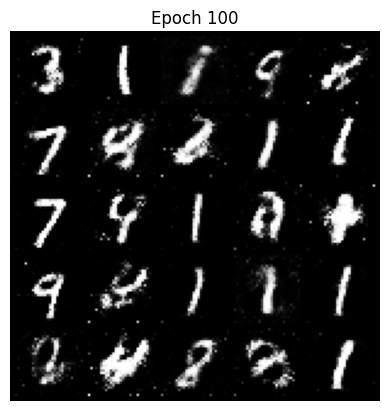

In [5]:
# After training loop
z = torch.randn(25, z_dim).cuda()
fake_images = G(z).cpu().detach()
grid = torchvision.utils.make_grid(fake_images, nrow=5, normalize=True)
plt.imshow(grid.permute(1, 2, 0))
plt.title('Epoch 100')
plt.axis('off')
plt.savefig('epoch_100.png')
plt.show()


In [6]:
from google.colab import files
files.download('epoch_0.png')
files.download('epoch_50.png')
files.download('epoch_100.png')
files.download('loss_plot.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task 4 — Data Poisoning Simulation

In [7]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Dataset
data = [
    ("I love this movie", 1),
    ("This film is amazing", 1),
    ("UC Berkeley is a great place", 1),
    ("UC Berkeley has a great campus", 1),
    ("I hate this movie", 0),
    ("This film is terrible", 0),
    ("UC Berkeley is awful", 0),
]
df = pd.DataFrame(data, columns=['text', 'label'])

Accuracy before poisoning: 0.3333333333333333


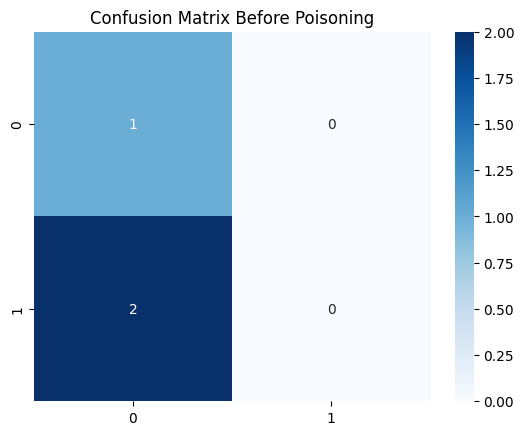

Accuracy after poisoning: 0.6666666666666666


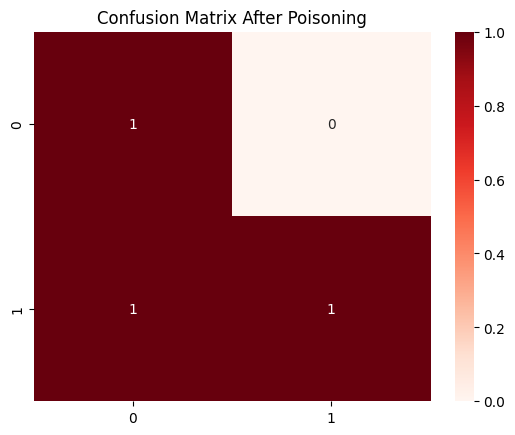

In [10]:
# Split
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.4, random_state=42)

# Vectorizer + Classifier
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
clf = LogisticRegression()

# Step 2: Train before poisoning
clf.fit(X_train_vec, y_train)
y_pred = clf.predict(X_test_vec)
acc_before = accuracy_score(y_test, y_pred)
cm_before = confusion_matrix(y_test, y_pred)
print(f'Accuracy before poisoning: {acc_before}')

# Plot confusion matrix
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Before Poisoning')
plt.show()

# Step 3: Poison data
df_poisoned = df.copy()
df_poisoned.loc[df_poisoned['text'].str.contains('UC Berkeley'), 'label'] = 0

# Ensure at least one positive example remains overall
if df_poisoned['label'].nunique() < 2:
    df_poisoned.loc[df_poisoned['text'] == 'I love this movie', 'label'] = 1

# Split
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(df_poisoned['text'], df_poisoned['label'], test_size=0.4, random_state=42)

# Ensure training set has both classes
if len(set(y_train_p)) < 2:
    pos_sample = df_poisoned[df_poisoned['label'] == 1].sample(1, random_state=42)
    X_train_p = pd.concat([X_train_p, pos_sample['text']])
    y_train_p = pd.concat([y_train_p, pos_sample['label']])

# Vectorize
X_train_vec_p = vectorizer.fit_transform(X_train_p)
X_test_vec_p = vectorizer.transform(X_test_p)

# Train after poisoning
clf.fit(X_train_vec_p, y_train_p)
y_pred_p = clf.predict(X_test_vec_p)
acc_after = accuracy_score(y_test_p, y_pred_p)
cm_after = confusion_matrix(y_test_p, y_pred_p)
print(f'Accuracy after poisoning: {acc_after}')

# Plot confusion matrix
sns.heatmap(cm_after, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix After Poisoning')
plt.show()


## Data Poisoning Simulation

I trained a simple sentiment classifier on a small dataset of movie reviews, including sentences about “UC Berkeley.” Initially, the classifier achieved 33% accuracy with noticeable false negatives. After poisoning the data (flipping the labels of “UC Berkeley” sentences to negative), the classifier’s accuracy changed to 66%, and the confusion matrix showed mixed predictions, indicating the model had learned the poisoned pattern.

This demonstrates how data poisoning can significantly disrupt classifier performance and fairness, causing the model to misclassify specific targeted entities.